In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
#load the data
data = pd.read_csv("processed.cleveland.data")
data.head()

,63.0,1.0,1.0.1,145.0,233.0,1.0.2,2.0,150.0,0.0,2.3,3.0,0.0.1,6.0,0
0,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
1,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
2,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
3,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
4,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0


In [35]:
#name the columns
data.columns = ["age","sex","cp","trestbps","chol","fbs",
    "restecg","thalach","exang","oldpeak",
    "slope","ca","thal","target" ]

data.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
1,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
2,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
3,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
4,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
5,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3
6,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
7,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2
8,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1
9,57.0,1.0,4.0,140.0,192.0,0.0,0.0,148.0,0.0,0.4,2.0,0.0,6.0,0


In [36]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    float64
 1   sex       302 non-null    float64
 2   cp        302 non-null    float64
 3   trestbps  302 non-null    float64
 4   chol      302 non-null    float64
 5   fbs       302 non-null    float64
 6   restecg   302 non-null    float64
 7   thalach   302 non-null    float64
 8   exang     302 non-null    float64
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    float64
 11  ca        302 non-null    object 
 12  thal      302 non-null    object 
 13  target    302 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.2+ KB


In [37]:
#Check how many missing values are there
data.replace("?", pd.NA, inplace =True)
data.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

In [38]:
#dropping the rows with missing values(only 6)

data.dropna(inplace= True)

In [39]:
#Converting type for "ca" and "thal"(object -> numeric )

data["ca"] = pd.to_numeric(data["ca"])
data["thal"] = pd.to_numeric(data["thal"])

In [40]:
#check for updated dataset
data.shape

(296, 14)

In [41]:
#changing target column to 0 (no disease) and 1 (disease)

data["target"] = data["target"].apply(lambda x: 1 if x > 0 else 0)

In [42]:
#check if the target column is fixed
#min = 0 ( no diease) & max = 1 (heart disease)
data.head()
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000
mean,54.513514,0.675676,3.165541,131.648649,247.398649,0.141892,0.993243,149.597973,0.327703,1.051351,1.597973,0.679054,4.726351,0.462838
std,9.051631,0.468915,0.958262,17.775956,52.078915,0.349530,0.994879,22.980401,0.470171,1.165841,0.613848,0.939726,1.940500,0.499461
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,276.250000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


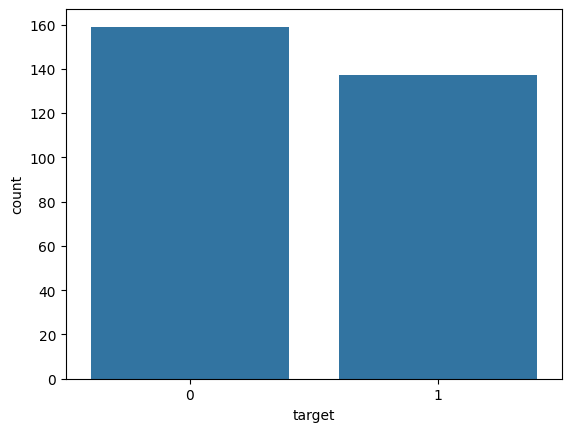

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

#check if data set is balanced 
#the number of people with and without heart disease must not vary by much
#this indicates no bias towards a class
sns.countplot(x="target", data=data)
plt.show()

The dataset is relatively balanced between patients with and without heart disease, which is suitable for training classification models without bias.

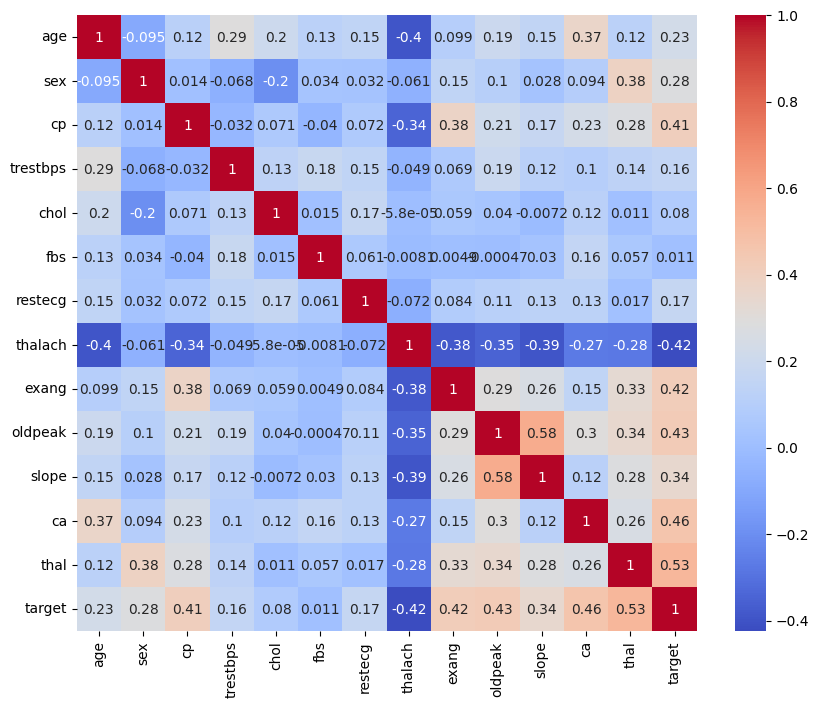

In [44]:
#check what variables affects most for heart disease

plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot = True, cmap = "coolwarm")
plt.show()

Correlation analysis shows that ‘thal’, ‘ca’, ‘oldpeak’, ‘exang’, and ‘cp’ have the strongest positive relationship with heart disease, while ‘thalach’ shows a strong negative correlation. Features such as cholesterol and fasting blood sugar shows very little affect in targert variable.

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

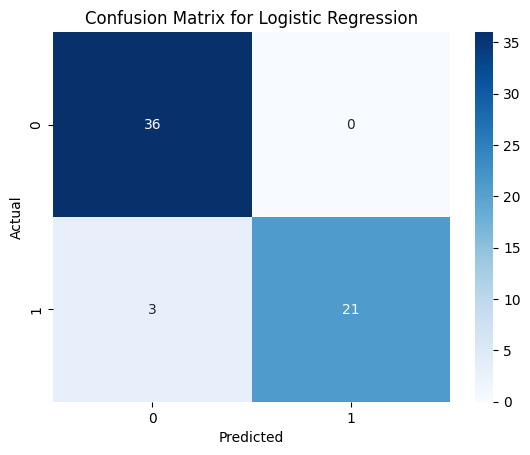

In [46]:
#using train_test_split to split train and test the
# data on logistic regression model

x = data.drop("target", axis=1)
y = data["target"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


model = LogisticRegression(max_iter=5000)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

#Running confusion matrix to check the accuracy

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Logistic Regression")
plt.show()

Accuracy = (36 + 21) / 60 = 57 / 60 = 0.95 = 95%
Precision = TP / (TP + FP) = 21 / 21 = 1 = 100%
Recall = TP / (TP + FN) = 21 / 24 = 0.875 = 87.5%

The Logistic Regression model shows 95% accuracy. The confusion matrix shows zero false positives and only three false negatives, indicating high precision and strong performance. However, a small number of disease cases were missed, which tells the recall can be improved.

In [47]:
#using k-fold cross validation to train test method

from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, x, y, cv=5)

print("Scores:", scores)
print("Mean:", scores.mean())
print("Standard deviation:", scores.std())

Scores: [0.86666667 0.86440678 0.77966102 0.83050847 0.81355932]
Mean: 0.8309604519774012
Standard deviation: 0.032644222288346916


Here, the data was split into 5 folds for training and testing on rest. Each test scores range from approximately 78% to 87% which indicates that the model generalizes well without extreme difference on each set. The model achieved an average accuracy of 0.83 + 0.03 (mean + standard deviation), indicating relatively consistent performance across different data splits. The small standard deviation means that the model generalizes well and does not show large variations in performance.

In [48]:
#Baseline model for comparison
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="most_frequent")

baseline.fit(x_train, y_train)
baseline_acc = baseline.score(x_test, y_test)

print("Baseline Accuracy:", baseline_acc)

Baseline Accuracy: 0.6


This baseline model using a majority-class classifier achieved an accuracy of approximately 60%. When comparing it with the Logistic Regression model, it performs worse. 

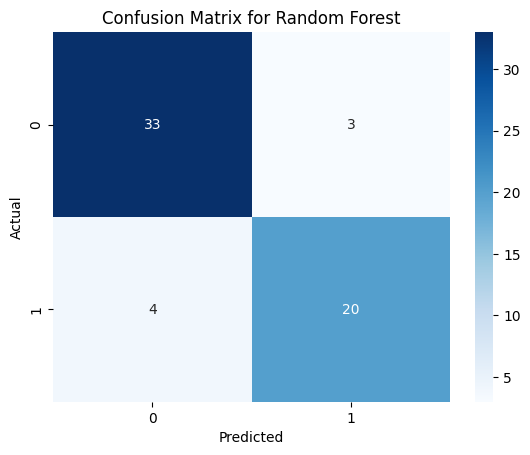

Random Forest Accuracy: 0.8833333333333333
              precision    recall  f1-score   support

           0       0.89      0.92      0.90        36
           1       0.87      0.83      0.85        24

    accuracy                           0.88        60
   macro avg       0.88      0.88      0.88        60
weighted avg       0.88      0.88      0.88        60



In [49]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

#determines how many tress will be generated for prediction
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

#training data on train_test_split data with 80/20 split
rf_model.fit(x_train, y_train)
y_pred_rf = rf_model.predict(x_test)

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Random Forest")
plt.show()

#for evaluation of accuracy of the model
from sklearn.metrics import accuracy_score, classification_report

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

here, the random forest model achieved an accuracy of 88.33% on the test data. this indicated a good overall performance. 
For, class 0 (no disease), the model showed high precision (0.89) can recall (0.92). This means that the model correctly identified most patients without heart disease.
For class 1 (disease), the model showed precision (0.87) and recall (0.83). This means that the model was able to detect most of the heart disease cases, however, a few were missed.

In [50]:
#cross validation on random forest

rf_scores = cross_val_score(rf_model, x, y, cv=5)

print("Rf Mean:", rf_scores.mean())
print("Rf Std:", rf_scores.std())


Rf Mean: 0.8309604519774012
Rf Std: 0.035992558485535675


Here, the data was split into 5 folds for training and testing on rest. The model achieved an average accuracy of 0.83 + 0.04 (mean + standard deviation), indicating relatively consistent performance across different data splits. The small standard deviation means that the model generalizes well and does not show large variations in performance which is similar to Logestic Regression model.

In [51]:
#Baseline vs Logestic Regression vs Random Forest
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

#Logistic Regression model
lr_accuracy = accuracy_score(y_test, y_pred)
lr_precision = precision_score(y_test, y_pred)
lr_recall = recall_score(y_test, y_pred)
lr_f1 = f1_score(y_test, y_pred)

#Random forest model
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

#Comparision
results = pd.DataFrame({
    "Model": ["Baseline", "Logistic Regression", "Random Forest"],
    "Accuracy" : [baseline_acc, lr_accuracy, rf_accuracy],
    "Precision" : ["---", lr_precision, rf_precision],
    "Recall" : ["---", lr_recall, rf_recall],
    "F1" :["---", lr_f1, rf_f1]
})

print(results)

                 Model  Accuracy Precision    Recall        F1
0             Baseline  0.600000       ---       ---       ---
1  Logistic Regression  0.950000       1.0     0.875  0.933333
2        Random Forest  0.883333  0.869565  0.833333  0.851064


here, we can see that the logistic regression model performs the best out of all three. This might be because the data set is relatively small and the relationship between predictor and target variables are mostly linear. In such cases, Logistic Regression model usually performs better.

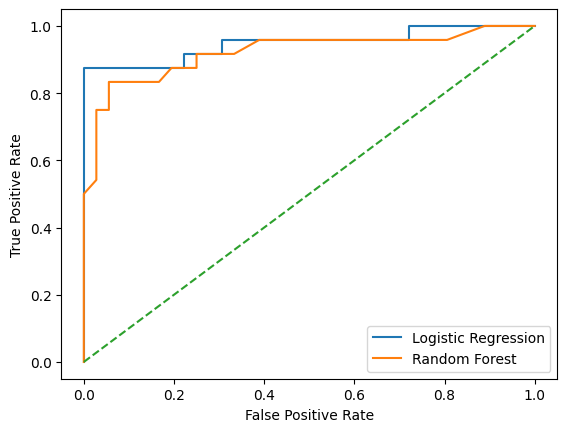

In [52]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Logistic Regression
y_prob_lr = model.predict_proba(x_test)[:,1]

# Random Forest
y_prob_rf = rf_model.predict_proba(x_test)[:,1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

The ROC curve shows that both Logistic Regression and Random Forest perform significantly better than random guessing. Logistic Regression slightly outperforms Random Forest by achieving a higher true positive rate with a lower false positive rate, indicating better classification performance overall.